# tutorial from https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html

In [5]:
import matplotlib.pyplot as plt
from scipy.misc import electrocardiogram
from scipy.signal import find_peaks, peak_prominences
import numpy as np
import pandas as pd
import scipy.fftpack
import scipy.fft
import matplotlib.patches as patches
#from track_plotting_daniel import*

To demonstrate this function’s usage we use a signal x supplied with SciPy (see scipy.misc.electrocardiogram). Let’s find all peaks (local maxima) in x whose amplitude lies above 0.

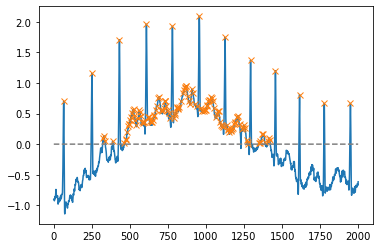

In [12]:
x = electrocardiogram()[2000:4000]
peaks, _ = find_peaks(x, height=0)
plt.plot(x)
plt.plot(peaks, x[peaks], "x")
plt.plot(np.zeros_like(x), "--", color="gray")
#plt.show()

# with the chemotaxis data

In [2]:
path='/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected_concentration/2020-07-01_13-21-00_chemotaxisl_worm1-TablePosRecord.csvconcentration.csv'
concentration_change=pd.read_csv(path)
concentration_change

,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected,x_center,y_center,concentration_head,concentration_tail,concentration_center,concentration_change_head,concentration_change_tail,concentration_change_center
0,12.259347,12.330343,12.301606,12.593304,12.3617,12.4125,0.002846,0.002764,0.002651,NaN,NaN,NaN
1,12.583785,12.263278,12.625420,12.490605,12.6873,12.3068,0.002273,0.002209,0.002116,-0.000573,-5.551789e-04,-0.000535
2,12.582258,12.263278,12.625268,12.490605,12.6873,12.3068,0.002276,0.002209,0.002116,0.000002,2.323178e-07,0.000000
3,12.579995,12.263278,12.624561,12.490605,12.6873,12.3068,0.002279,0.002210,0.002116,0.000004,1.082094e-06,0.000000
4,12.577847,12.263278,12.624416,12.490666,12.6873,12.3068,0.002283,0.002210,0.002116,0.000003,2.219788e-07,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
199996,0.185842,16.672020,0.402163,16.455799,0.0021,16.3924,0.925709,0.914698,0.934018,-0.000042,5.416837e-06,0.000004
199997,0.188273,16.671920,0.402163,16.455699,0.0021,16.3923,0.925592,0.914698,0.934018,-0.000116,0.000000e+00,0.000000
199998,0.192050,16.671920,0.402063,16.455100,0.0020,16.3923,0.925412,0.914703,0.934023,-0.000181,5.416525e-06,0.000004
199999,0.193533,16.668119,0.401963,16.455100,0.0019,16.3923,0.925341,0.914708,0.934027,-0.000071,5.416213e-06,0.000004


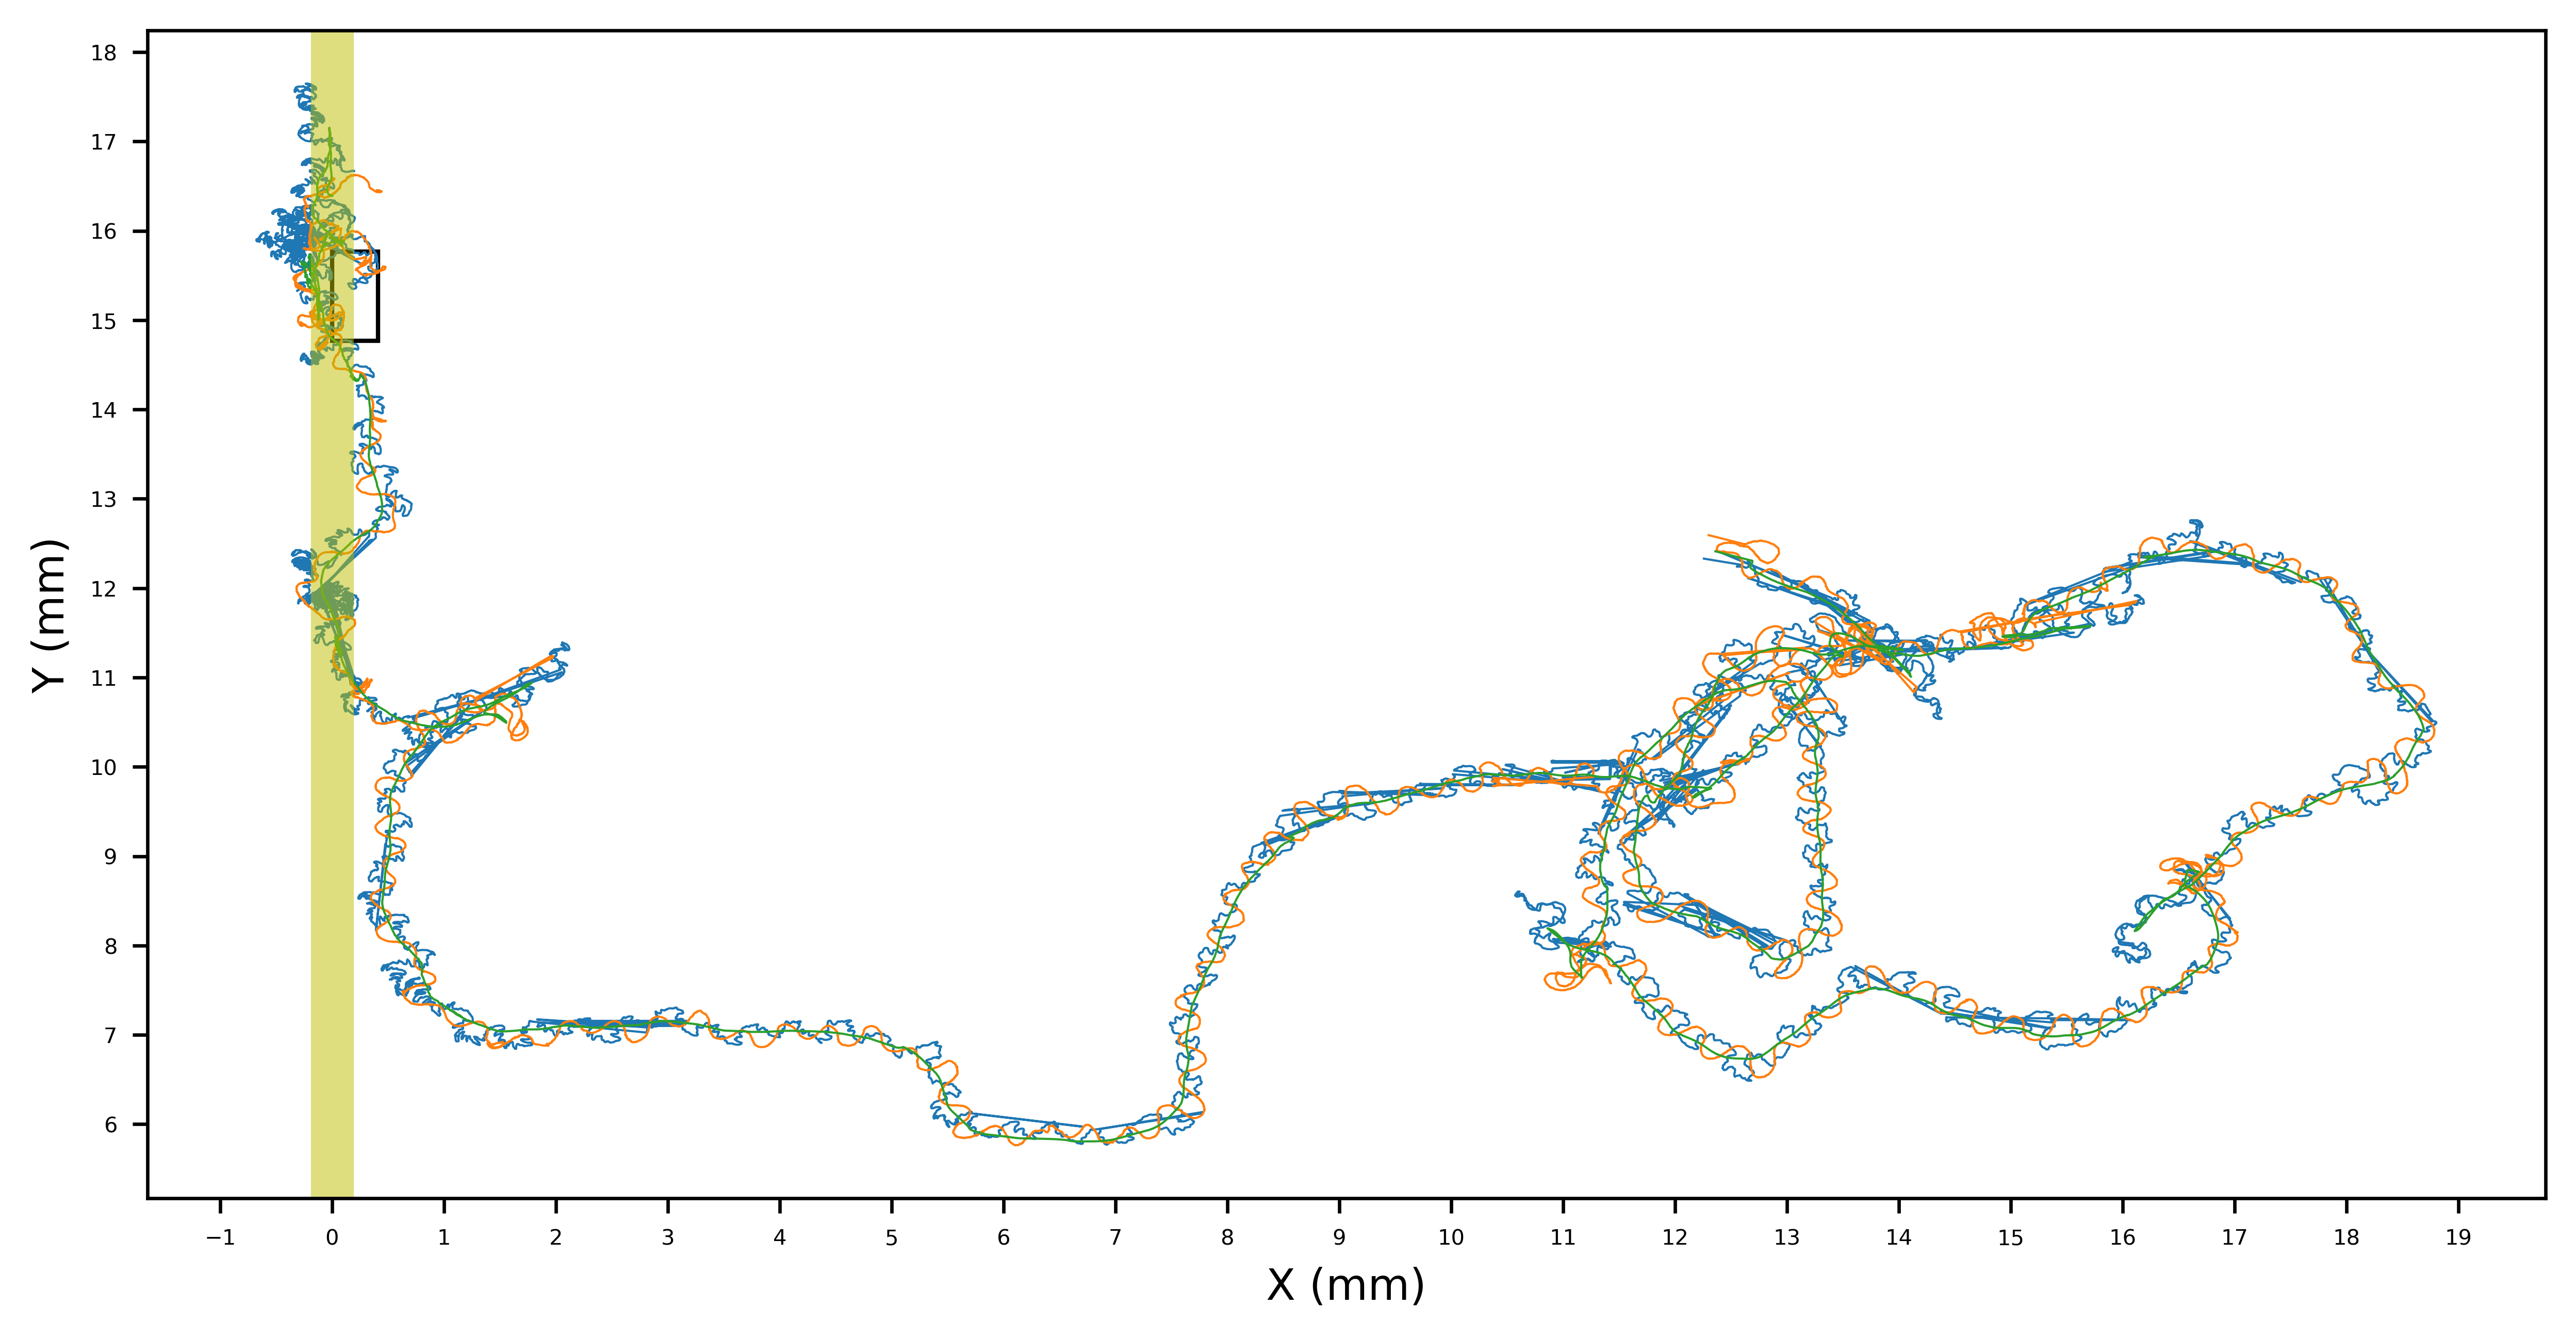

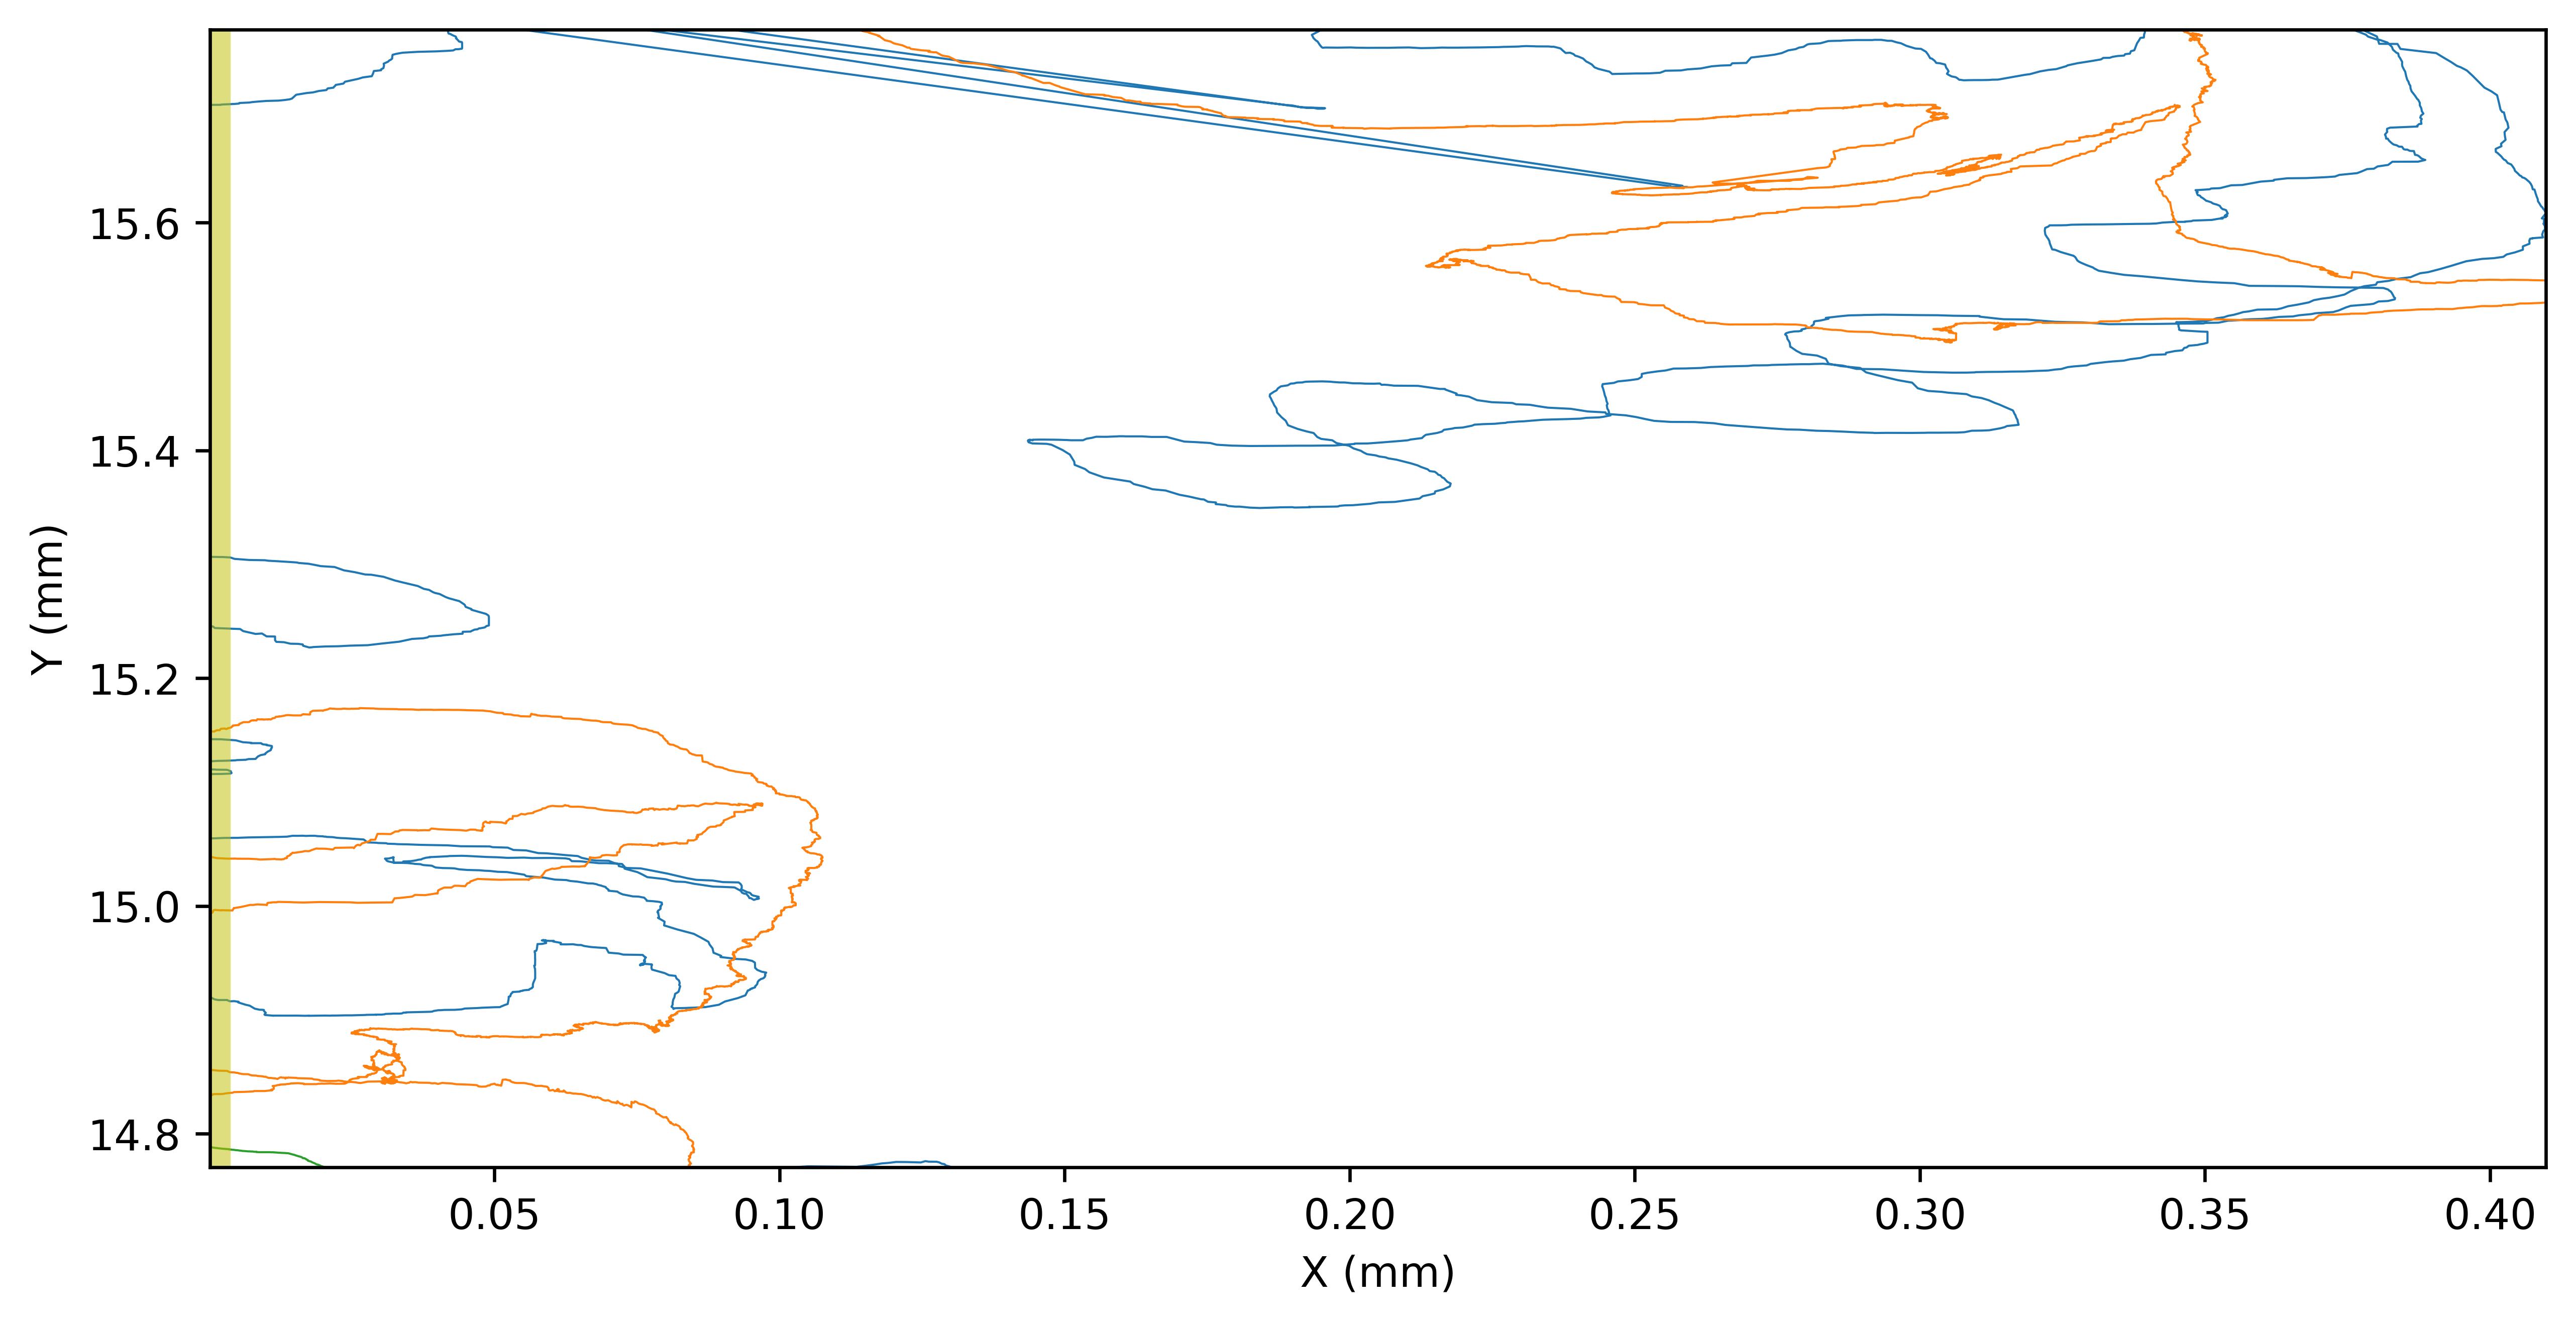

In [14]:
begin_x=0
end_x=3
begin_y=14.77
end_y=15.77
position=position_to_time(concentration_change,begin_x,end_x,begin_y,end_y)
plot_track_section(concentration_change,position)

In [2]:
#load curvature data
#csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv'
csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_13-21-00_chemotaxisl_worm1_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]

In [8]:
def curv_section(K,fps,start_frame,end_frame):
    Ks=K[start_frame:end_frame]
    print(('lenght of recording:'+str((end_frame-start_frame)/fps)+" secs")) #defines the part of the track i want to fourier transform
    print('rows and columns: '+str(Ks.shape))
    return(Ks.copy)


In [9]:
fps=167.0 #frames per second
start_frame=position.index.min()
end_frame=position.index.max()
Ks=curv_section(K,fps,start_frame,end_frame)

NameError: name 'position' is not defined

In [6]:
win=5
K_avg=segment_averaging(Ks,win)

NameError: name 'Ks' is not defined

In [18]:
def plot_peaks(K,fps,start_frame,end_frame):
    for idx, segment in enumerate(K):
        #skip some segments
        #if idx%10!=5:continue
        #if idx >20:continue
        y=segment
        #define x and y
        y=y[start_frame:end_frame]
        #plotting:
        plt.rcParams.update({'figure.max_open_warning': 0})
        plt.rcParams.update({'font.size': 16})
        plt.figure(figsize=(20,3))
        #x=np.arange(0,(end_frame-start_frame)/fps,1/fps)
        plt.plot(y)
        plt.xticks(np.arange(0,(end_frame-start_frame)/fps,1/fps))
        peaks, _ = find_peaks(y, height=0,prominence=0.005)
        plt.plot(peaks, y[peaks], "x")
        plt.title('Segment '+str((idx*win))+'-'+str(idx*win+win))
        if idx==0: plt.title('Segment '+str(idx)+'-'+str(win))
        plt.xlabel('Time (s)')
        plt.ylabel('Signal Amplitude (a.u)')

In [9]:
x=np.arange(0,(end_frame-start_frame)/fps,1/fps)

NameError: name 'end_frame' is not defined

In [172]:
np.arange(0, end_frame-start_frame)/fps,1/fps)step=500))

SyntaxError: invalid syntax (<ipython-input-172-6dc98fc4f107>, line 1)

In [160]:
(end_frame-start_frame)/fps

17.964071856287426

In [ ]:
start_frame=0
end_frame=3000
fps=167.0 #frames per second
plot_peaks(K_avg,fps,start_frame,end_frame)